# 03 — Importância das Features

Consolida os rankings de Random Forest, XGBoost e Permutation Importance já calculados no conjunto de teste, e calcula coeficientes PLS padronizados. O PLS é ajustado exclusivamente sobre o conjunto de treino e usa a configuração selecionada no tuning.

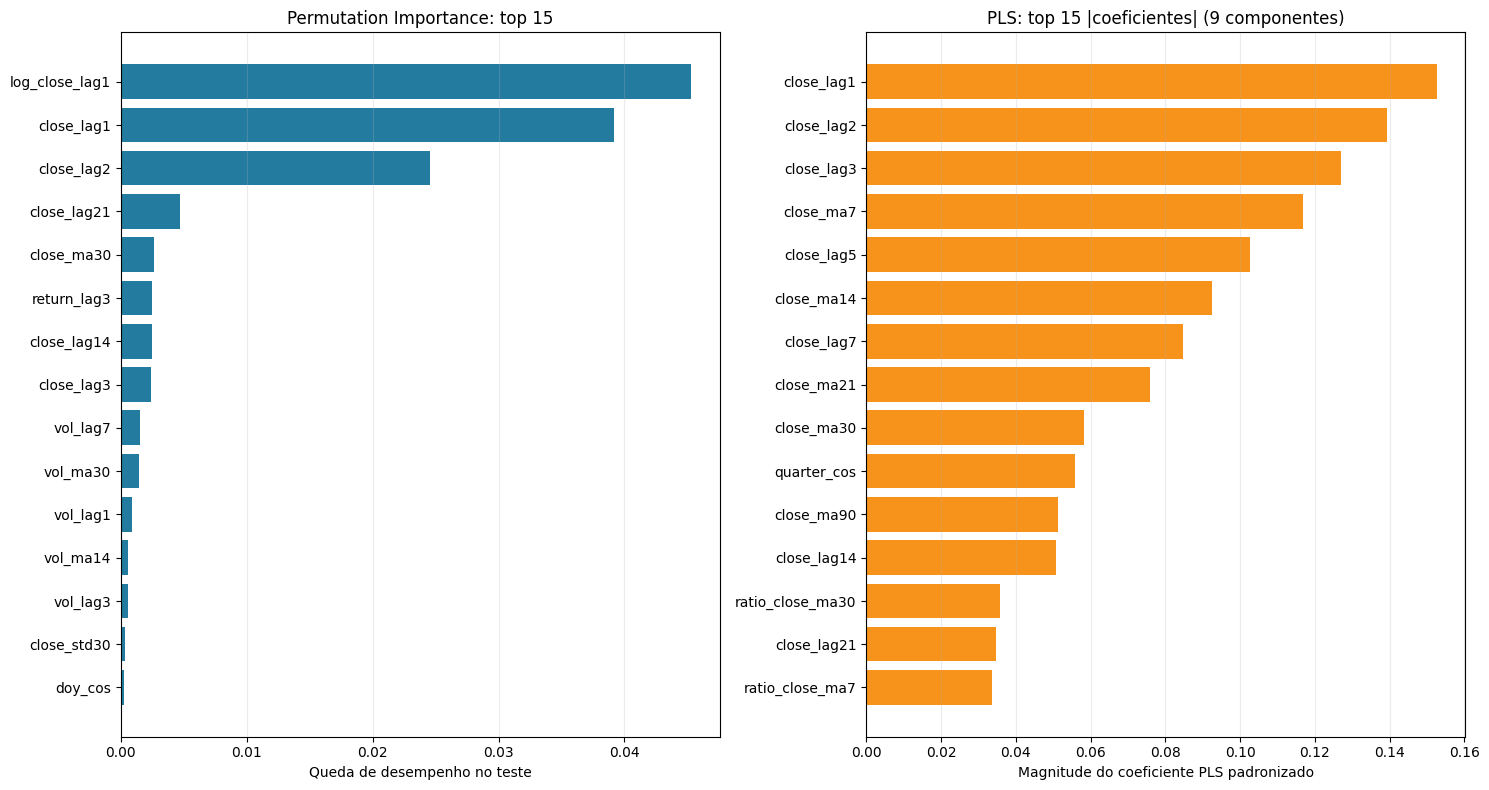

PLS ajustado somente no treino: 1996 linhas, 51 features, 9 componentes.
Top 10 por Permutation Importance:
       feature  Permutation_Test  feature_de_mercado                                       disponibilidade
log_close_lag1          0.045326               False Defasada ou derivada de observacoes disponiveis ate t
    close_lag1          0.039196               False Defasada ou derivada de observacoes disponiveis ate t
    close_lag2          0.024547               False Defasada ou derivada de observacoes disponiveis ate t
   close_lag21          0.004689               False Defasada ou derivada de observacoes disponiveis ate t
    close_ma30          0.002639               False Defasada ou derivada de observacoes disponiveis ate t
   return_lag3          0.002493                True Defasada ou derivada de observacoes disponiveis ate t
   close_lag14          0.002446               False Defasada ou derivada de observacoes disponiveis ate t
    close_lag3          0.002398    

In [2]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression

cwd = Path.cwd().resolve()
project_root = next(
    (path for path in (cwd, *cwd.parents)
     if (path / 'analyses').is_dir() and (path / 'bases').is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError('Nao foi possivel localizar a raiz do projeto.')

data_dir = project_root / 'analyses' / 'grupo1' / '01_dados'
model_dir = project_root / 'analyses' / 'grupo1' / '02_modelos' / 'PLS_Regression'
results_dir = project_root / 'analyses' / 'grupo1' / '03_resultados'
results_dir.mkdir(parents=True, exist_ok=True)

metadata = json.loads((data_dir / 'feature_metadata.json').read_text(encoding='utf-8'))
pls_config = json.loads((model_dir / 'pls_config_final.json').read_text(encoding='utf-8'))
feature_names = metadata['feature_cols']
target_name = metadata['target_col']

importance_path = data_dir / 'feature_importance.csv'
importance = pd.read_csv(importance_path).rename(columns={'Unnamed: 0': 'feature'})
importance['feature'] = importance['feature'].astype(str)
if set(importance['feature']) != set(feature_names):
    raise ValueError('O ranking de importancia nao corresponde ao metadata de features.')

train = pd.read_csv(data_dir / 'bitcoin_features_train.csv')
missing_columns = set(feature_names + [target_name]).difference(train.columns)
if missing_columns:
    raise ValueError(f'Colunas ausentes no treino: {sorted(missing_columns)}')

n_components = int(pls_config['n_components'])
if n_components > min(len(train), len(feature_names)):
    raise ValueError('O numero de componentes PLS excede o limite do treino.')
pls = PLSRegression(n_components=n_components, scale=bool(pls_config.get('scale', True)))
pls.fit(train[feature_names].astype(float), train[target_name].astype(float))
raw_coefficients = np.asarray(pls.coef_).reshape(-1)
if len(raw_coefficients) != len(feature_names):
    raise ValueError('Dimensao dos coeficientes PLS diferente da lista de features.')

x_scale = train[feature_names].std(ddof=1).to_numpy()
y_scale = train[target_name].std(ddof=1)
if not np.isfinite(y_scale) or y_scale == 0 or not np.isfinite(x_scale).all() or (x_scale == 0).any():
    raise ValueError('Nao foi possivel padronizar os coeficientes PLS com escalas nulas ou invalidas.')
pls_coefficients = raw_coefficients * x_scale / y_scale

pls_importance = pd.DataFrame({
    'feature': feature_names,
    'PLS_coeficiente_padronizado': pls_coefficients,
})
pls_importance['PLS_abs'] = pls_importance['PLS_coeficiente_padronizado'].abs()
importance_final = importance.merge(pls_importance, on='feature', validate='one_to_one')
calendar_features = {
    'day_of_week', 'day_of_month', 'day_of_year', 'month', 'quarter', 'year',
    'week_of_year', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'doy_sin', 'doy_cos', 'is_weekend', 'quarter_sin', 'quarter_cos',
}
importance_final['disponibilidade'] = np.where(
    importance_final['feature'].isin(calendar_features),
    'Conhecida antecipadamente (calendario)',
    'Defasada ou derivada de observacoes disponiveis ate t',
)
importance_final['feature_de_mercado'] = importance_final['feature'].str.contains(
    r'^(?:vol_|range_|oc_ratio|vol_pressure|return_lag)', regex=True
)
importance_final = importance_final.sort_values('Permutation_Test', ascending=False)
importance_final.to_csv(results_dir / 'importancia_features_consolidada.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
top_tree = importance_final.nlargest(15, 'Permutation_Test').sort_values('Permutation_Test')
axes[0].barh(top_tree['feature'], top_tree['Permutation_Test'], color='#247ba0')
axes[0].set_title('Permutation Importance: top 15')
axes[0].set_xlabel('Queda de desempenho no teste')
axes[0].grid(axis='x', alpha=0.25)
top_pls = importance_final.nlargest(15, 'PLS_abs').sort_values('PLS_abs')
axes[1].barh(top_pls['feature'], top_pls['PLS_abs'], color='#f7931a')
axes[1].set_title(f'PLS: top 15 |coeficientes| ({n_components} componentes)')
axes[1].set_xlabel('Magnitude do coeficiente PLS padronizado')
axes[1].grid(axis='x', alpha=0.25)
fig.tight_layout()
fig.savefig(results_dir / '03_importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'PLS ajustado somente no treino: {len(train)} linhas, {len(feature_names)} features, {n_components} componentes.')
print('Top 10 por Permutation Importance:')
print(importance_final[['feature', 'Permutation_Test', 'feature_de_mercado', 'disponibilidade']].head(10).to_string(index=False))
print('\nTop 10 por magnitude do coeficiente PLS padronizado:')
print(importance_final.nlargest(10, 'PLS_abs')[['feature', 'PLS_coeficiente_padronizado', 'feature_de_mercado']].to_string(index=False))

## Leitura dos resultados

Permutation Importance mede a perda de desempenho ao embaralhar uma feature e depende do conjunto de teste; features correlacionadas podem dividir importância. No PLS, os coeficientes assinados descrevem associação linear condicional ao modelo, não causalidade. A marcação de disponibilidade temporal é documental: todas as entradas do modelo devem permanecer defasadas conforme o pipeline de features.